# Eigenfaces: a face in a handful of numbers

**Solution notebook.** A 64x64 face is **4096 numbers**, but faces live near a much smaller subspace. PCA finds it; its components, drawn as images, look like ghostly faces (**eigenfaces**). We will **compress** faces, **visualize** them with t-SNE / UMAP, and finally **recognize** them --- a balanced tour of dimensionality reduction.

Seed is fixed to `509`. Every figure is written to the **`out/`** subfolder.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score
import umap

SEED = 509
np.random.seed(SEED)

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)   # all results are written here

# Armenian flag colors, for plots with <= 3 series
ARM_RED, ARM_BLUE = "#D90012", "#0033A0"

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the faces

X: (400, 4096) | people: 40 | images per person: 10


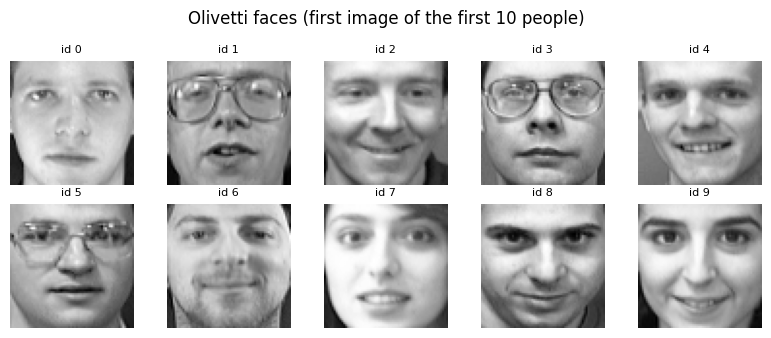

In [2]:
faces = fetch_olivetti_faces()
X = faces.data            # (400, 4096), values in [0, 1]
images = faces.images     # (400, 64, 64)
y = faces.target          # (400,) person id 0..39
H = W = 64
print(f"X: {X.shape} | people: {len(np.unique(y))} | images per person: {np.bincount(y)[0]}")

fig, axes = plt.subplots(2, 5, figsize=(8, 3.4))
for ax, person in zip(axes.ravel(), range(10)):
    ax.imshow(images[np.where(y == person)[0][0]], cmap="gray")
    ax.set_title(f"id {person}", fontsize=8)
    ax.axis("off")
plt.suptitle("Olivetti faces (first image of the first 10 people)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "face_samples.png"), dpi=120, bbox_inches="tight")
plt.show()

## 2. The mean face and the eigenfaces

Fit PCA on every face. The **mean face** is the average image; each **principal component**, reshaped to 64x64, is an **eigenface** --- a direction of variation (lighting, glasses, beard, pose). Every face is the mean plus a weighted sum of these.

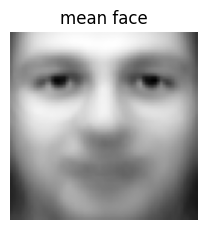

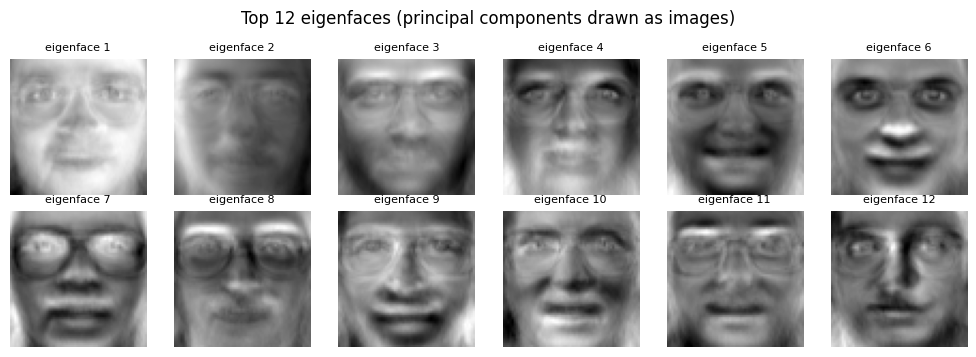

In [3]:
pca_all = PCA(random_state=SEED).fit(X)   # all components (min(n_samples, n_features) = 400)

fig, ax = plt.subplots(figsize=(2.4, 2.4))
ax.imshow(pca_all.mean_.reshape(H, W), cmap="gray")
ax.set_title("mean face")
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "mean_face.png"), dpi=120, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 6, figsize=(10, 3.6))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(pca_all.components_[k].reshape(H, W), cmap="gray")
    ax.set_title(f"eigenface {k+1}", fontsize=8)
    ax.axis("off")
plt.suptitle("Top 12 eigenfaces (principal components drawn as images)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eigenfaces.png"), dpi=120, bbox_inches="tight")
plt.show()

## 3. How many components? (scree)

The **scree plot** shows variance per component (it drops fast); the **cumulative** curve tells us how many components reach, say, 95% of the variance.

components needed for 95% of the variance: 123  (out of 400)


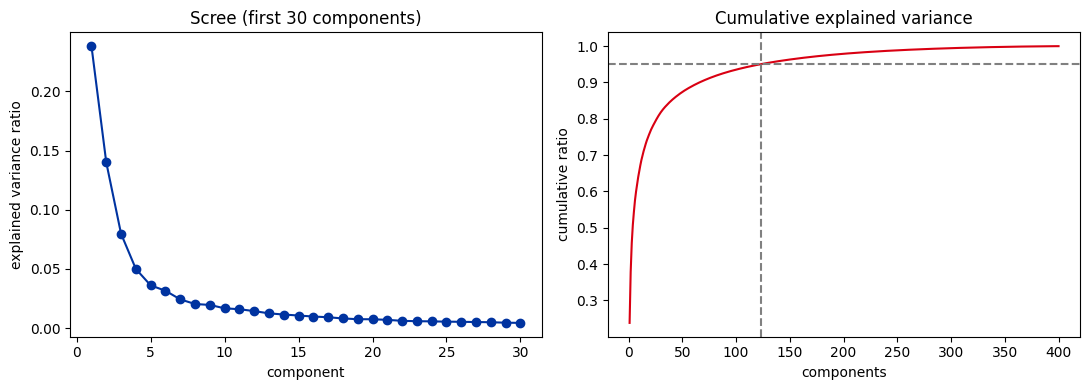

In [4]:
ratios = pca_all.explained_variance_ratio_
cum = np.cumsum(ratios)
k95 = int(np.argmax(cum >= 0.95) + 1)
print(f"components needed for 95% of the variance: {k95}  (out of {len(ratios)})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, 31), ratios[:30], marker="o", color=ARM_BLUE)
ax[0].set(title="Scree (first 30 components)", xlabel="component", ylabel="explained variance ratio")
ax[1].plot(range(1, len(cum) + 1), cum, color=ARM_RED)
ax[1].axhline(0.95, ls="--", color="gray")
ax[1].axvline(k95, ls="--", color="gray")
ax[1].set(title="Cumulative explained variance", xlabel="components", ylabel="cumulative ratio")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "scree.png"), dpi=120)
plt.show()

## 4. Reconstruction: a face in `k` numbers

Project a face onto the top `k` eigenfaces (that is just `k` numbers --- the **scores**), then lift it back: `x_hat = mean + sum_i z_i * v_i`. Watch how few components it takes to still look like the person.

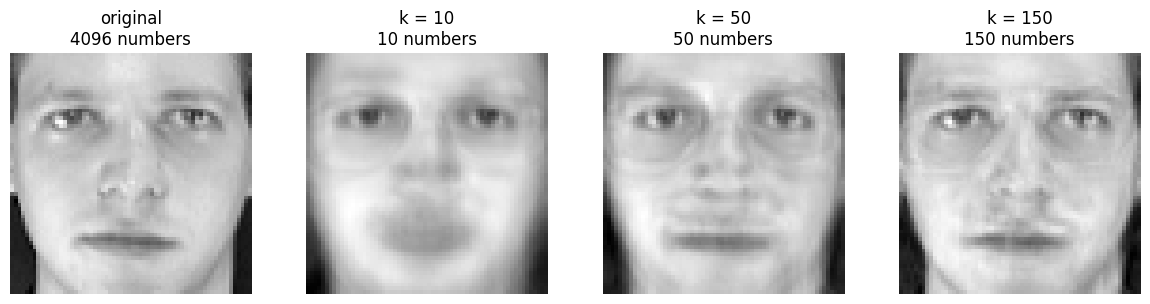

k=  2: MSE=0.01198
k=  5: MSE=0.00879
k= 10: MSE=0.00662
k= 25: MSE=0.00398
k= 50: MSE=0.00243
k=100: MSE=0.00125
k=150: MSE=0.00071
k=200: MSE=0.00040


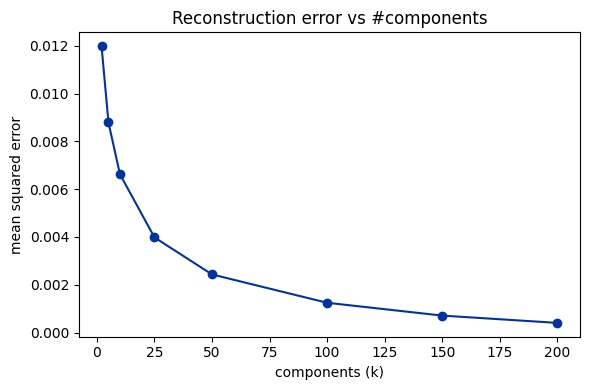

In [5]:
ks = [10, 50, 150]
orig = X[0]

fig, axes = plt.subplots(1, len(ks) + 1, figsize=(3 * (len(ks) + 1), 3))
axes[0].imshow(orig.reshape(H, W), cmap="gray")
axes[0].set_title("original\n4096 numbers")
axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    Wk = pca_all.components_[:k]
    z = Wk @ (orig - pca_all.mean_)              # k scores
    rec = pca_all.mean_ + z @ Wk                 # lift back
    ax.imshow(rec.reshape(H, W), cmap="gray")
    ax.set_title(f"k = {k}\n{k} numbers")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "reconstruction.png"), dpi=120, bbox_inches="tight")
plt.show()

# reconstruction error over ALL faces vs k
ks_curve = [2, 5, 10, 25, 50, 100, 150, 200]
Xc = X - pca_all.mean_
mses = []
for k in ks_curve:
    Wk = pca_all.components_[:k]
    Xrec = (Xc @ Wk.T) @ Wk
    mses.append(np.mean((Xc - Xrec) ** 2))
    print(f"k={k:>3}: MSE={mses[-1]:.5f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks_curve, mses, marker="o", color=ARM_BLUE)
ax.set(title="Reconstruction error vs #components", xlabel="components (k)", ylabel="mean squared error")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "reconstruction_error.png"), dpi=120)
plt.show()

## 5. Visualizing face space

Project the faces to 2-D three ways and color by person. PCA is linear; t-SNE and UMAP preserve **local neighborhoods**, so they pull each person's shots into tighter islands. We use the first 10 people so the colors stay readable.

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


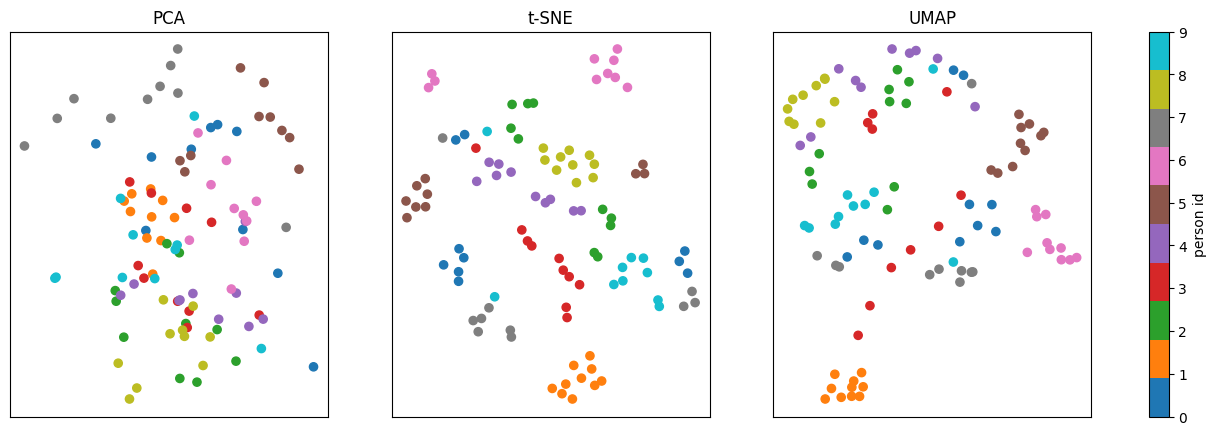

In [6]:
mask = y < 10                 # first 10 people = 100 images
Xv, yv = X[mask], y[mask]

emb = {}
emb["PCA"] = PCA(n_components=2, random_state=SEED).fit_transform(Xv)
emb["t-SNE"] = TSNE(n_components=2, perplexity=15, init="pca", random_state=SEED).fit_transform(Xv)
emb["UMAP"] = umap.UMAP(n_components=2, n_neighbors=15, random_state=SEED).fit_transform(Xv)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, Z) in zip(axes, emb.items()):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=yv, cmap="tab10", s=35)
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, label="person id", fraction=0.02)
plt.savefig(os.path.join(OUT_DIR, "embeddings.png"), dpi=120, bbox_inches="tight")
plt.show()

## 6. Payoff: a face recognizer

Split each person's 10 shots into train/test, fit PCA **on the training faces only**, and classify a test face by its **nearest neighbor in PCA space**. This is the original eigenfaces application (Turk & Pentland, 1991) and a clean example of **DR as preprocessing**: a few dozen components **match** all 4096 raw pixels at a fraction of the cost (they edge slightly ahead at k=50, but with only ~100 test images that margin is within noise).

baseline: 1-NN on raw 4096 pixels -> accuracy 0.880
PCA k= 10 -> accuracy 0.850


PCA k= 25 -> accuracy 0.880


PCA k= 50 -> accuracy 0.900


PCA k=100 -> accuracy 0.880


PCA k=150 -> accuracy 0.880


PCA k=200 -> accuracy 0.880


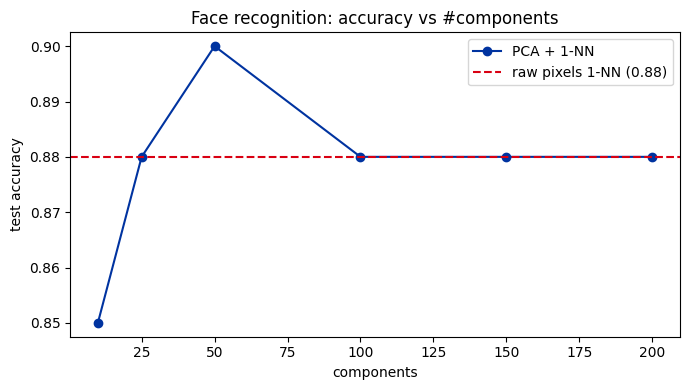

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

base = KNeighborsClassifier(n_neighbors=1).fit(X_tr, y_tr)
base_acc = accuracy_score(y_te, base.predict(X_te))
print(f"baseline: 1-NN on raw 4096 pixels -> accuracy {base_acc:.3f}")

comps = [10, 25, 50, 100, 150, 200]
accs = []
for k in comps:
    p = PCA(n_components=k, random_state=SEED).fit(X_tr)
    knn = KNeighborsClassifier(n_neighbors=1).fit(p.transform(X_tr), y_tr)
    accs.append(accuracy_score(y_te, knn.predict(p.transform(X_te))))
    print(f"PCA k={k:>3} -> accuracy {accs[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(comps, accs, marker="o", color=ARM_BLUE, label="PCA + 1-NN")
ax.axhline(base_acc, ls="--", color=ARM_RED, label=f"raw pixels 1-NN ({base_acc:.2f})")
ax.set(title="Face recognition: accuracy vs #components", xlabel="components", ylabel="test accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "recognition_accuracy.png"), dpi=120)
plt.show()

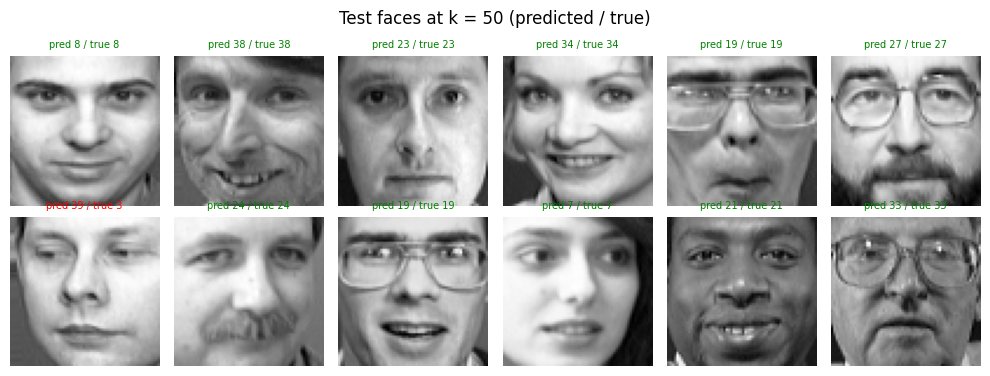

In [8]:
# a quick look at predictions at the best k (green = correct, red = wrong)
best_k = comps[int(np.argmax(accs))]
p = PCA(n_components=best_k, random_state=SEED).fit(X_tr)
knn = KNeighborsClassifier(n_neighbors=1).fit(p.transform(X_tr), y_tr)
pred = knn.predict(p.transform(X_te))

fig, axes = plt.subplots(2, 6, figsize=(10, 3.8))
for ax, i in zip(axes.ravel(), range(12)):
    ax.imshow(X_te[i].reshape(H, W), cmap="gray")
    ax.axis("off")
    ok = pred[i] == y_te[i]
    ax.set_title(f"pred {pred[i]} / true {y_te[i]}", fontsize=7, color=("green" if ok else "red"))
plt.suptitle(f"Test faces at k = {best_k} (predicted / true)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "predictions.png"), dpi=120, bbox_inches="tight")
plt.show()

## 7. Callback: clustering in PCA space

A nod to the previous chapter. Run k-means (`k = 40`) on the PCA-reduced faces **without using the labels**, then score it against the true identities with the **adjusted Rand index** (chance-adjusted: 0 = random, 1 = perfect).

In [9]:
Z = PCA(n_components=100, random_state=SEED).fit_transform(X)
km = KMeans(n_clusters=40, n_init=10, random_state=SEED).fit(Z)
ari = adjusted_rand_score(y, km.labels_)
print(f"k-means (k=40) in PCA space vs true identities: ARI = {ari:.3f}")
print("(Unsupervised clustering partly recovers people, but identity is harder than it looks.)")

k-means (k=40) in PCA space vs true identities: ARI = 0.434
(Unsupervised clustering partly recovers people, but identity is harder than it looks.)


In [10]:
print("Files written to out/:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", f, f"({os.path.getsize(os.path.join(OUT_DIR, f))/1024:,.0f} KB)")

Files written to out/:
   eigenfaces.png (189 KB)
   embeddings.png (86 KB)
   face_samples.png (156 KB)
   mean_face.png (8 KB)
   predictions.png (253 KB)
   recognition_accuracy.png (37 KB)
   reconstruction.png (41 KB)
   reconstruction_error.png (32 KB)
   scree.png (48 KB)


## Conclusion

- A face is 4096 pixels but lives near a low-dimensional subspace: the **eigenfaces**. The mean face plus a weighted sum of a few dozen of them reconstructs a recognizable person.
- The **scree / cumulative** curves show ~95% of the variance fits in far fewer than 4096 components, and reconstruction error falls steeply then flattens.
- **t-SNE and UMAP** pull each person's shots into tighter islands than linear PCA-2D --- better for *seeing* identity structure.
- As **preprocessing**, a few dozen PCA components **match** all 4096 raw pixels for nearest-neighbor recognition at far lower cost (they edge ahead at k=50, within noise here) --- the original eigenfaces result.
- Unsupervised k-means in PCA space only *partly* recovers identities (ARI well below 1): clustering finds structure, but it is not label-aware.
- All figures are saved under **`out/`**.